# Automatic Relevance Determination (ARD)

## Trabajo Practico N.2, Analisis Predictivo

En este notebook estudiamos el modelo ARD (Automatic Relevance Determination), una tecnica de regresion bayesiana que permite seleccionar automaticamente las variables relevantes de un problema.

Al final se presenta una extension reciente: **NARD (Network ARD)** para modelos multi output con estructura de correlacion entre las respuestas.

## 1. Librerias y configuracion

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, ARDRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Marco teorico, de la regresion lineal al ARD

Antes de arrancar fijamos la notacion. Llamamos $n$ a la cantidad de observaciones (filas del dataset) y $p$ a la cantidad de variables o features (columnas). El vector $y$ tiene lo que queremos predecir, por ejemplo la progresion de la diabetes de cada paciente. La matriz $X$ tiene los datos, con una fila por observacion y una columna por variable. El vector $w$ tiene los pesos (weights) que queremos aprender, donde $w_j$ dice cuanto pesa la variable $j$ en la prediccion. Por ultimo $\epsilon$ es el ruido, la parte de $y$ que el modelo no puede explicar.

### 2.1 Regresion lineal (OLS)

El modelo lineal clasico dice que cada observacion se genera como una suma pesada de las variables mas un ruido gaussiano (con forma de campana) de media cero. La idea de OLS (Ordinary Least Squares, o minimos cuadrados) es elegir el $w$ que hace que las predicciones $Xw$ esten lo mas cerca posible de los $y$ observados, midiendo cercania con la suma de cuadrados de las diferencias.

$$ \hat{w}_{OLS} = \arg\min_w \; \|y - Xw\|^2 $$

El problema con OLS aparece cuando hay muchas variables o cuando algunas estan muy correlacionadas entre si (multicolinealidad). En esos casos los coeficientes explotan (toman valores enormes con signos que se cancelan), el modelo se ajusta perfecto al training pero generaliza pesimo. Ademas OLS le da peso a todas las variables por igual y no distingue las relevantes de las que son puro ruido.

### 2.2 Ridge Regression

La idea de Ridge es agregarle al problema de OLS una penalizacion que castigue coeficientes grandes. En vez de solo minimizar el error, minimiza el error mas una penalidad proporcional a la suma de los cuadrados de los pesos.

$$ \hat{w}_{Ridge} = \arg\min_w \underbrace{\|y - Xw\|^2}_{\text{ajuste a los datos}} + \underbrace{\lambda \sum_{j=1}^p w_j^2}_{\text{penalizacion}} $$

El parametro $\lambda \geq 0$ controla el balance entre las dos partes. Cuando $\lambda$ vale cero no hay penalizacion y es igual a OLS. Cuando $\lambda$ es grande la penalizacion domina y todos los pesos son forzados hacia cero. Eso es el shrinkage. Ridge encoge los pesos de manera uniforme, todos se hacen mas chicos pero ninguno llega a ser exactamente cero. Por eso Ridge no hace seleccion de variables.

Ridge tambien tiene una lectura bayesiana que propone tratar a $w$ como una variable aleatoria con una distribucion, en vez de buscar "el mejor $w$". La prior es la distribucion que suponemos para $w$ antes de ver los datos, es decir nuestras creencias iniciales. El posterior es la distribucion de $w$ despues de ver los datos, es lo que aprendimos.

Ridge equivale a poner una prior gaussiana centrada en cero, con la misma varianza $\tau^2$ para todos los pesos. A priori creemos que cada peso es cercano a cero, y la escala tipica de esos valores es $\tau$. El punto importante es que todos los pesos comparten exactamente la misma prior, por eso todos se encogen igual.

### 2.3 Bayesian Ridge

Bayesian Ridge es la version totalmente bayesiana de Ridge. En vez de fijar $\lambda$ a mano, deja que el modelo lo aprenda de los datos.

La precision de una gaussiana es el inverso de la varianza. Precision grande significa varianza chica, es decir una distribucion muy concentrada. Precision chica significa varianza grande, una distribucion muy dispersa. 

En el modelo Bayesian Ridge aparecen dos precisiones. Una es $\alpha$, la precision del ruido, que dice cuan concentrada esta la distribucion de los errores. La otra es $\lambda$, la precision comun de todos los pesos, que dice cuan apretados en cero estan los $w_j$ antes de ver los datos. Los dos hiperparametros se estiman con lo que se llama empirical Bayes, o sea, se busca el par $(\alpha, \lambda)$ que hace mas probables los datos observados, promediando sobre todos los $w$ posibles. Esa "probabilidad de los datos" es la evidencia marginal.

La ventaja frente a Ridge clasico es que no hace falta cross validation para elegir $\lambda$, el modelo lo saca solo. La desventaja es que sigue habiendo una unica precision comun a todos los pesos, todos se siguen shrinkeando igual.

### 2.4 ARD (Automatic Relevance Determination)

La idea central del ARD es que en vez de una unica precision $\lambda$ para todos los pesos, se pone una precision $\lambda_j$ distinta por cada variable.

$$ w_j \sim \mathcal{N}(0, \; \lambda_j^{-1}) $$

Cada peso tiene su propia campana gaussiana con su propio ancho, y esos anchos se aprenden de los datos. Durante el entrenamiento pasa lo siguiente. Si la variable $j$ es relevante, es decir aporta a explicar $y$, el modelo mantiene $\lambda_j$ chico, o sea varianza grande, y le deja libertad al peso para tomar valores no nulos. Si la variable $j$ es irrelevante, $\lambda_j$ crece mucho, la varianza tiende a cero y el peso queda forzado a cero. Esa variable queda descartada del modelo.

A la propiedad de que muchos pesos terminen valiendo cero se la llama sparsity (solo unos pocos pesos quedan no nulos). Y a la propiedad de que el modelo decida por si solo cuales variables usar se la llama seleccion automatica de variables, que es de donde le viene el nombre al ARD.

Todos los $\lambda_j$ mas $\alpha$ se optimizan igual que en Bayesian Ridge, maximizando la evidencia marginal con un algoritmo iterativo tipo EM (Expectation Maximization).

## 3. Ventajas, desventajas y cuando usarlo

### Ventajas

1. **Seleccion automatica de variables:** el modelo aprende cuales features son relevantes sin intervencion manual
2. **No requiere tuning de parámetros:** todo se estima via evidencia marginal, no hace falta validacion cruzada para lambda
3. **Estimacion de incertidumbre:** al ser bayesiano, devuelve la distribucion posterior de los coeficientes y de las predicciones (intervalos de credibilidad)
4. **Interpretabilidad:** los coeficientes que sobreviven tienen una interpretacion clara
5. **Muy util con muchas variables potencialmente irrelevates** (high dimensional problems)

### Desventajas

1. **Costo computacional alto:** cada iteracion involucra invertir matrices $O(p^3)$ o $O(n^3)$. Escala mal cuando $p$ o $n$ son muy grandes (miles de features/observaciones)
2. **Puede ser inestable con features altamente correlacionadas:** si dos variables llevan la misma informacion, ARD puede oscilar en cual conservar
3. **Asume linealidad y ruido gaussiano:** como todo modelo lineal, no captura relaciones no lineales sin transformar los features
4. **Convergencia local:** el algoritmo EM puede quedarse en optimos locales
5. **No es tan agresivo como Lasso** para producir sparsity, los coeficientes tienden a cero pero no llegan exactamente, por eso usualmente se aplica un threshold

### Cuando usarlo

- Datasets con muchas variables candidatas, sospechando que solo unas pocas son informativas
- Contextos donde la interpretabilidad importa (medicina, biologia, ciencias sociales)
- Cuando queremos incertidumbre sobre las predicciones, no solo un valor puntual
- Cuando el problema es aproximadamente lineal

### Cuando NO usarlo

- Datasets muy grandes en cantidad de observaciones (mejor metodos escalables)
- Problemas fuertemente no lineales
- Cuando todas las variables son claramente relevantes (Ridge es mas simple y funciona bien)

## 4. Caso cuadratico con base polinomica de alto grado

Comparamos los cuatro modelos (OLS, Ridge, Bayesian Ridge, ARD) sobre el mismo diseno 

### 4.1 Datos sinteticos

$$ y = w_0 + w_1 x + w_2 x^2 + \epsilon, \quad w_0 = -0.5, \; w_1 = 1.0, \; w_2 = 2.0, \; \sigma = 0.1 $$

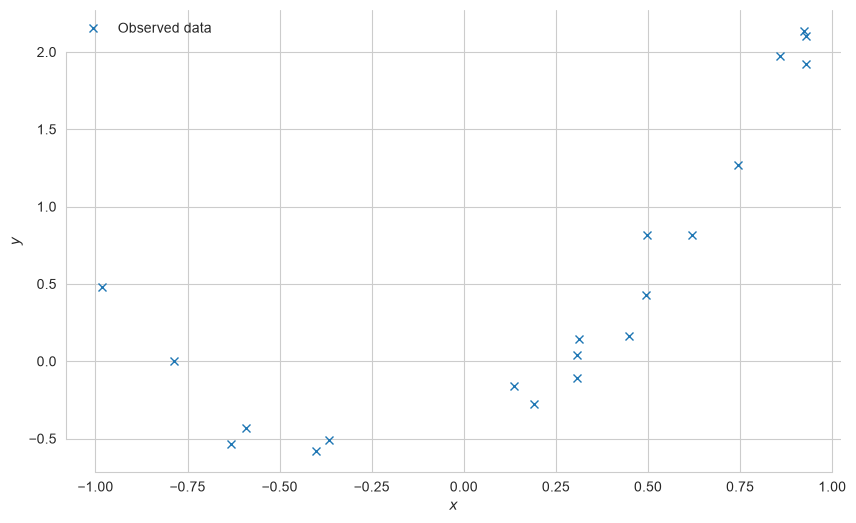

In [104]:
np.random.seed(12345)

num_obs = 20
x = -1.0 + 2 * np.random.rand(num_obs)
w0_true = -0.5
w1_true = 1.0
w2_true = 2.0
sigma_true = 0.1
y = (
    w0_true
    + w1_true * x
    + w2_true * x ** 2
    + sigma_true * np.random.randn(num_obs)
)

fig, ax = plt.subplots()
ax.plot(x, y, 'x', label='Observed data')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.legend(loc='best', frameon=False)
sns.despine(trim=True);

### 4.2 Funciones auxiliares: bases y graficacion

Definimos tres tipos de bases (polinomica, Fourier, RBF) y las utilidades para graficar el posterior predictive y muestras del posterior.

In [105]:
def get_polynomial_design_matrix(x, degree):
    """Matriz de diseno polinomica de grado degree evaluada en x."""
    assert isinstance(x, np.ndarray), 'x is not a numpy array.'
    assert x.ndim == 2, 'You must make x a 2D array.'
    assert x.shape[1] == 1, 'x must be a column.'
    cols = []
    for i in range(degree + 1):
        cols.append(x ** i)
    return np.hstack(cols)

def get_fourier_design_matrix(x, L, num_terms):
    """Expansion de Fourier con num_terms cosenos y senos."""
    assert isinstance(x, np.ndarray), 'x is not a numpy array.'
    assert x.ndim == 2, 'You must make x a 2D array.'
    assert x.shape[1] == 1, 'x must be a column.'
    N = x.shape[0]
    cols = [np.ones((N, 1))]
    for i in range(int(num_terms / 2)):
        cols.append(np.cos(2 * (i + 1) * np.pi / L * x))
        cols.append(np.sin(2 * (i + 1) * np.pi / L * x))
    return np.hstack(cols)

def get_rbf_design_matrix(x, x_centers, ell):
    """Matriz de diseno de funciones de base radial."""
    assert isinstance(x, np.ndarray), 'x is not a numpy array.'
    assert x.ndim == 2, 'You must make x a 2D array.'
    assert x.shape[1] == 1, 'x must be a column.'
    N = x.shape[0]
    cols = [np.ones((N, 1))]
    for i in range(x_centers.shape[0]):
        cols.append(np.exp(-(x - x_centers[i]) ** 2 / ell))
    return np.hstack(cols)

In [106]:
def plot_posterior_predictive(model, xx, phi_func, phi_func_args=(), y_true=None):
    """Posterior predictive separando incertidumbre aleatoria y epistemica."""
    Phi_xx = phi_func(xx[:, None], *phi_func_args)
    yy_mean, yy_measured_std = model.predict(Phi_xx, return_std=True)
    sigma = np.sqrt(1.0 / model.alpha_)
    yy_std = np.sqrt(np.clip(yy_measured_std ** 2 - sigma ** 2, 0, None))
    yy_le = yy_mean - 2.0 * yy_std
    yy_ue = yy_mean + 2.0 * yy_std
    yy_lae = yy_mean - 2.0 * yy_measured_std
    yy_uae = yy_mean + 2.0 * yy_measured_std

    fig, ax = plt.subplots()
    ax.plot(xx, yy_mean, 'r', label='Posterior mean')
    ax.fill_between(xx, yy_le, yy_ue, color='red', alpha=0.25,
                    label='95% epistemic credible interval')
    ax.fill_between(xx, yy_lae, yy_le, color='green', alpha=0.25)
    ax.fill_between(xx, yy_ue, yy_uae, color='green', alpha=0.25,
                    label='95% epistemic + aleatory credible interval')
    ax.plot(x, y, 'kx', label='Observed data')
    if y_true is not None:
        ax.plot(xx, y_true, '--', label='True response')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    plt.legend(loc='best', frameon=False)
    sns.despine(trim=True)

def plot_posterior_samples(model, xx, phi_func, phi_func_args=(),
                           num_samples=10, y_true=None, nugget=1e-6):
    """Muestras funcionales del posterior sobre los pesos.

    sklearn ARDRegression puede podar features cuando lambda_j supera el umbral,
    y en ese caso sigma_ tiene forma (n_kept, n_kept) en vez de (n_features, n_features).
    Sampleamos solo las dimensiones que quedaron activas y ponemos cero en las podadas.
    """
    Phi_xx = phi_func(xx[:, None], *phi_func_args)
    m = model.coef_
    S = model.sigma_
    n_features = len(m)

    if S.shape[0] < n_features:
        threshold = getattr(model, 'threshold_lambda', 1e4)
        keep = model.lambda_ < threshold
        m_active = m[keep]
    else:
        keep = np.ones(n_features, dtype=bool)
        m_active = m

    w_post = st.multivariate_normal(
        mean=m_active,
        cov=S + nugget * np.eye(S.shape[0])
    )

    fig, ax = plt.subplots()
    for _ in range(num_samples):
        w_active = w_post.rvs()
        w_sample = np.zeros(n_features)
        w_sample[keep] = w_active
        yy_sample = Phi_xx @ w_sample
        ax.plot(xx, yy_sample, 'r', lw=0.5)
    ax.plot([], [], 'r', lw=0.5, label='Posterior samples')
    ax.plot(x, y, 'kx', label='Observed data')
    if y_true is not None:
        ax.plot(xx, y_true, label='True response surface')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    plt.legend(loc='best', frameon=False)
    sns.despine(trim=True)

### 4.3 Comparacion de los cuatro modelos

Usamos una base polinomica de grado 16 (17 features). Solo los primeros 3 pesos ($w_0, w_1, w_2$) son verdaderamente distintos de cero. Los otros 14 son ruido puro que ARD deberia identificar y descartar.

In [107]:
degree = 16
Phi = get_polynomial_design_matrix(x[:, None], degree)
print(f'Phi shape: {Phi.shape}')
print(f'Numero total de bases: {degree + 1}')
print(f'Bases verdaderamente relevantes: 3 (grados 0, 1, 2)')
print(f'Bases irrelevantes: {degree - 2}')

true_coef = np.zeros(degree + 1)
true_coef[0] = w0_true
true_coef[1] = w1_true
true_coef[2] = w2_true

Phi shape: (20, 17)
Numero total de bases: 17
Bases verdaderamente relevantes: 3 (grados 0, 1, 2)
Bases irrelevantes: 14


In [108]:
modelos = {
    'OLS': LinearRegression(fit_intercept=False),
    'Ridge': Ridge(alpha=1.0, fit_intercept=False),
    'Bayesian Ridge': BayesianRidge(fit_intercept=False),
    'ARD': ARDRegression(fit_intercept=False)
}

resultados = {}
coefs = {}

xx = np.linspace(-1, 1, 200)
yy_true = w0_true + w1_true * xx + w2_true * xx ** 2
Phi_xx = get_polynomial_design_matrix(xx[:, None], degree)

for nombre, modelo in modelos.items():
    modelo.fit(Phi, y)
    y_pred_train = modelo.predict(Phi)
    y_pred_curve = modelo.predict(Phi_xx)
    resultados[nombre] = {
        'MSE_train': mean_squared_error(y, y_pred_train),
        'MAE_train': mean_absolute_error(y, y_pred_train),
        'R2_train': r2_score(y, y_pred_train),
        'MSE_curve_vs_true': mean_squared_error(yy_true, y_pred_curve)
    }
    coefs[nombre] = modelo.coef_

pd.DataFrame(resultados).T.round(4)

,MSE_train,MAE_train,R2_train,MSE_curve_vs_true
OLS,0.0100,0.0656,0.9878,10.4749
Ridge,0.0439,0.1760,0.9466,0.0618
Bayesian Ridge,0.0143,0.0900,0.9826,0.0087
ARD,0.0165,0.1038,0.9799,0.0009


El **`MSE_curve_vs_true`** compara la curva aprendida por cada modelo contra la funcion verdadera en el rango $[-1, 1]$. Esta metrica es mas honesta que el $R^2$ de training, porque un OLS con muchos features puede tener training error bajo pero recuperar una curva muy mala.

### 4.4 Curvas ajustadas por cada modelo

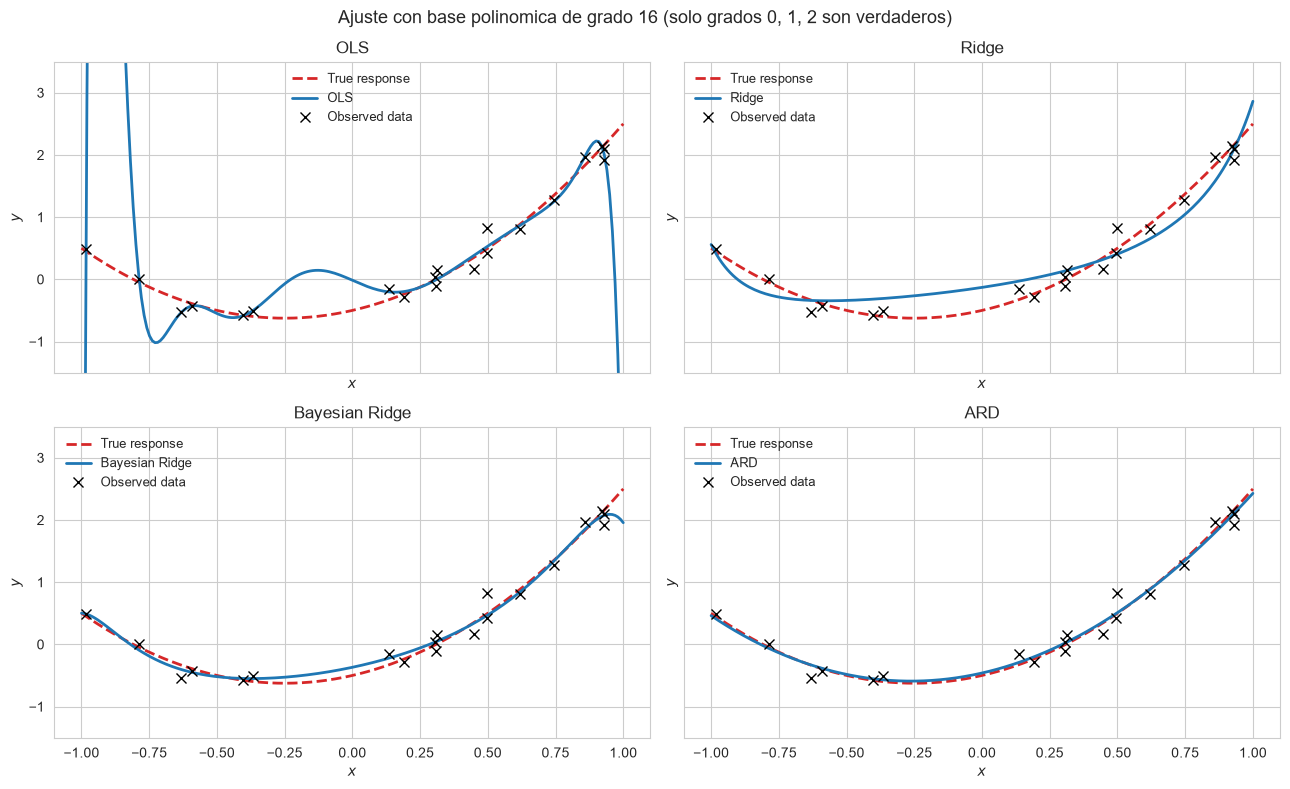

In [109]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos.items()):
    y_pred_curve = modelo.predict(Phi_xx)
    axes[i].plot(xx, yy_true, '--', color='C3', label='True response', lw=2)
    axes[i].plot(xx, y_pred_curve, '-', color='C0', label=f'{nombre}', lw=2)
    axes[i].plot(x, y, 'kx', label='Observed data', markersize=7)
    axes[i].set_title(nombre)
    axes[i].set_xlabel('$x$')
    axes[i].set_ylabel('$y$')
    axes[i].legend(loc='best', frameon=False, fontsize=9)
    axes[i].set_ylim(-1.5, 3.5)

plt.suptitle(f'Ajuste con base polinomica de grado {degree} (solo grados 0, 1, 2 son verdaderos)',
             fontsize=13)
plt.tight_layout()
plt.show()

### 4.5 Comparacion de coeficientes

OLS asigna coeficientes grandes (con signos alternados) a las bases irrelevantes tratando de pasar por todos los puntos. Ridge los amortigua pero mantiene todos no nulos. ARD manda a cero todos los grados $\geq 3$.

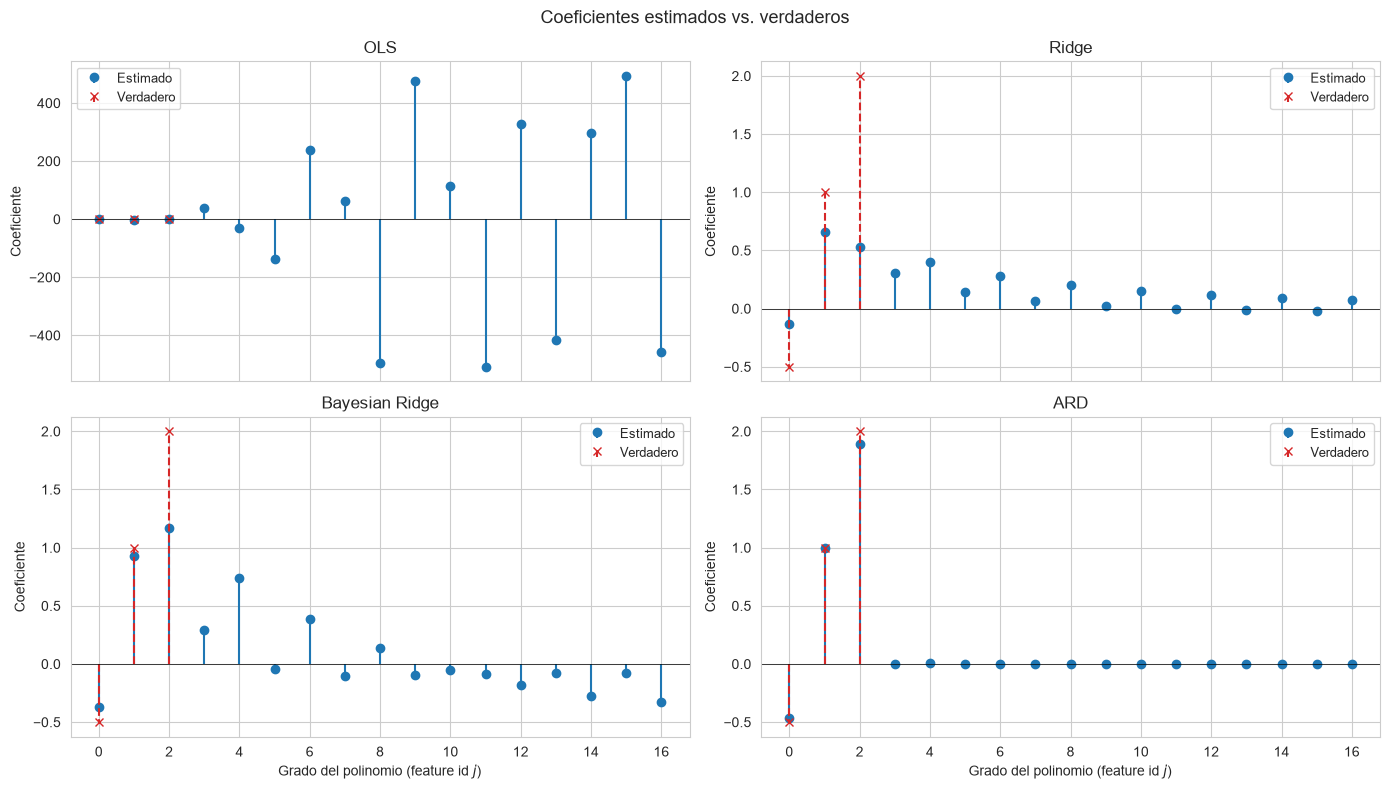

In [110]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, (nombre, coef) in enumerate(coefs.items()):
    axes[i].stem(range(degree + 1), coef, basefmt=' ', linefmt='C0-', markerfmt='C0o',
                 label='Estimado')
    axes[i].stem(np.where(true_coef != 0)[0], true_coef[true_coef != 0],
                 basefmt=' ', linefmt='C3--', markerfmt='C3x', label='Verdadero')
    axes[i].set_title(f'{nombre}')
    axes[i].set_ylabel('Coeficiente')
    axes[i].axhline(0, color='k', lw=0.5)
    axes[i].legend(loc='best', fontsize=9)

axes[2].set_xlabel('Grado del polinomio (feature id $j$)')
axes[3].set_xlabel('Grado del polinomio (feature id $j$)')
plt.suptitle('Coeficientes estimados vs. verdaderos', fontsize=13)
plt.tight_layout()
plt.show()

In [111]:
# Cuantas bases descarta cada modelo?
umbral = 1e-3
print(f'Bases con |coef| > {umbral} (verdaderas: 3):')
for nombre, coef in coefs.items():
    n_act = np.sum(np.abs(coef) > umbral)
    print(f'  {nombre:16s}: {n_act:2d} de {degree + 1}')

Bases con |coef| > 0.001 (verdaderas: 3):
  OLS             : 17 de 17
  Ridge           : 16 de 17
  Bayesian Ridge  : 17 de 17
  ARD             : 10 de 17


Con solo 20 observaciones, ARD no tiene suficiente evidencia para descartar del todo esas bases, y prefiere dejarlas con coeficientes chicos por las dudas. Pero los coeficientes que ARD dejo activos mas alla del grado 2 son valores muy chicos comparados con los verdaderos, casi despreciables. Es sparsity blanda donde los apaga pero no los elimina.

### 4.6 Precisiones $\alpha_j$

Cuanto mayor es la precision del prior $\alpha_j = \lambda_j$, mas se concentra ese peso alrededor de cero, es decir, la base $j$ es descartada del modelo.

sigma estimado = 0.140  (verdadero: 0.1)

Prior w precision (lambda_j): [4.65620508e+00 1.01156053e+00 2.77676179e-01 1.51283014e+05
 2.77613379e+02 3.30837165e+03 1.40148302e+04 3.04066573e+03
 1.88834463e+04 2.75211614e+03 2.15408364e+03 2.48472062e+03
 2.25238363e+03 2.24565729e+03 2.26926916e+03 2.03816048e+03
 2.24020225e+03]


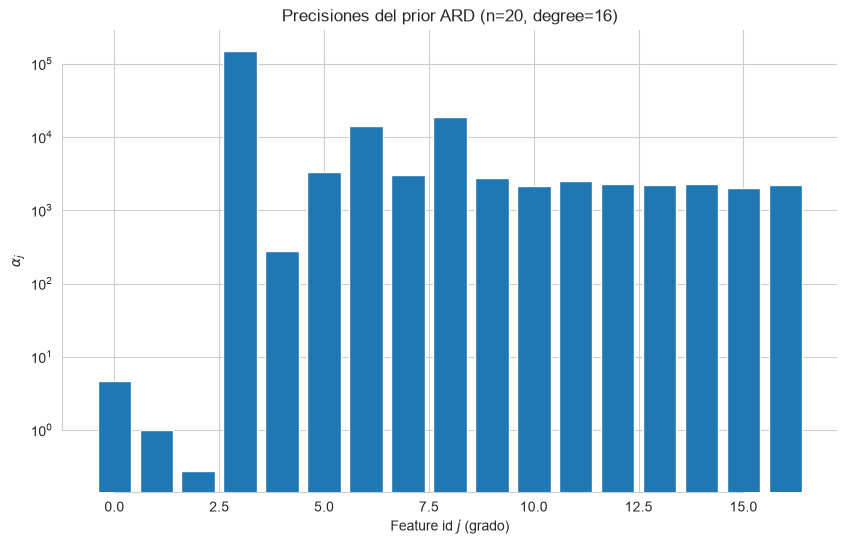

In [112]:
model_ard = modelos['ARD']

sigma_estimado = np.sqrt(1.0 / model_ard.alpha_)
print(f'sigma estimado = {sigma_estimado:.3f}  (verdadero: {sigma_true})')

alpha = model_ard.lambda_
print(f'\nPrior w precision (lambda_j): {alpha}')

fig, ax = plt.subplots()
ax.bar(np.arange(degree + 1), alpha, color='C0')
ax.set_xlabel('Feature id $j$ (grado)')
ax.set_ylabel(r'$\alpha_j$')
ax.set_yscale('log')
ax.set_title(f'Precisiones del prior ARD (n={num_obs}, degree={degree})')
sns.despine(trim=True);

In [113]:
m = model_ard.coef_
print(f'Posterior mean w:\n{m}')

S = model_ard.sigma_
print(f'\nPosterior std por peso (diag de S):\n{np.sqrt(np.diag(S))}')

Posterior mean w:
[-4.60618308e-01  9.92747171e-01  1.89433296e+00  0.00000000e+00
  7.87974188e-03 -1.11185556e-03  0.00000000e+00 -1.35715671e-03
  0.00000000e+00 -1.53390122e-03  9.65021140e-04 -1.68038216e-03
  8.28202053e-04 -1.81084544e-03  7.52921755e-04 -1.92628898e-03
  7.16323360e-04]

Posterior std por peso (diag de S):
[0.05135907 0.05504227 0.11846486 0.05945718 0.01729243 0.01802872
 0.01894745 0.021478   0.01994087 0.02100688 0.02097684 0.02093095
 0.02202116 0.02106837]


### 4.7 Posterior marginal de cada peso

Cada peso $w_j$ tiene su posterior marginal $\mathcal{N}(m_j, S_{jj})$. Los verdaderos valores ($w_0 = -0.5$, $w_1 = 1.0$, $w_2 = 2.0$) coinciden con los picos de las distribuciones de $w_0$, $w_1$ y $w_2$. Los pesos $w_3, w_4, \dots, w_{16}$ tienen densidades muy angostas centradas en cero (el ARD los apago).

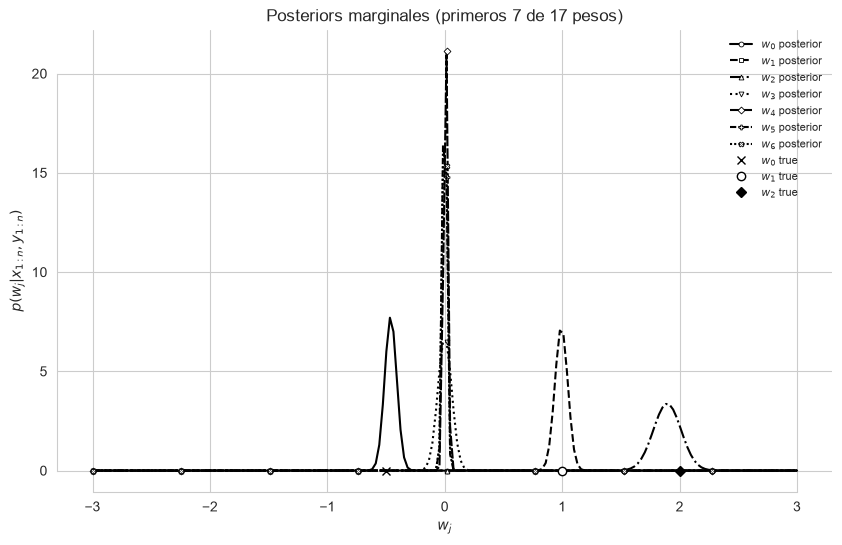

In [114]:
ww = np.linspace(-3.0, 3.0, 200)
line_styles = ['-', '--', '-.', ':', (0, (5, 1)), (0, (3, 1, 1, 1)), (0, (1, 1))]
line_markers = ['o', 's', '^', 'v', 'D', 'P', 'X']

# Solo graficamos los primeros pesos para no saturar la leyenda
n_show = min(7, degree + 1)

fig, ax = plt.subplots()
for j in range(n_show):
    wj_post = st.norm(loc=m[j], scale=np.sqrt(S[j, j]))
    ax.plot(
        ww, wj_post.pdf(ww),
        color='black',
        linestyle=line_styles[j % len(line_styles)],
        marker=line_markers[j % len(line_markers)],
        markevery=25, markersize=3.5,
        markerfacecolor='white', markeredgewidth=0.6,
        label=f'$w_{{{j}}}$ posterior'
    )
ax.plot([w0_true], [0], marker='x', linestyle='none', color='black',
        markersize=6, label='$w_0$ true')
ax.plot([w1_true], [0], marker='o', linestyle='none', color='black',
        markerfacecolor='white', markersize=6, label='$w_1$ true')
ax.plot([w2_true], [0], marker='D', linestyle='none', color='black',
        markerfacecolor='black', markersize=5, label='$w_2$ true')
ax.set_xlabel('$w_j$')
ax.set_ylabel('$p(w_j|x_{1:n}, y_{1:n})$')
ax.set_title(f'Posteriors marginales (primeros {n_show} de {degree+1} pesos)')
plt.legend(loc='best', frameon=False, fontsize=8)
sns.despine(trim=True);

### 4.8 Posterior predictive: incertidumbre epistemica vs aleatoria

La incertidumbre en la prediccion se descompone en dos:

- **Epistemica** (rojo): la que viene de no conocer perfectamente los pesos. Se reduce al aumentar los datos.
- **Aleatoria** (verde): el ruido irreducible $\sigma$ del proceso. No se reduce con mas datos.

$$ \text{Var}[y_* \mid x_*] = \underbrace{\phi(x_*)^T S \, \phi(x_*)}_{\text{epistemica}} + \underbrace{\sigma^2}_{\text{aleatoria}} $$

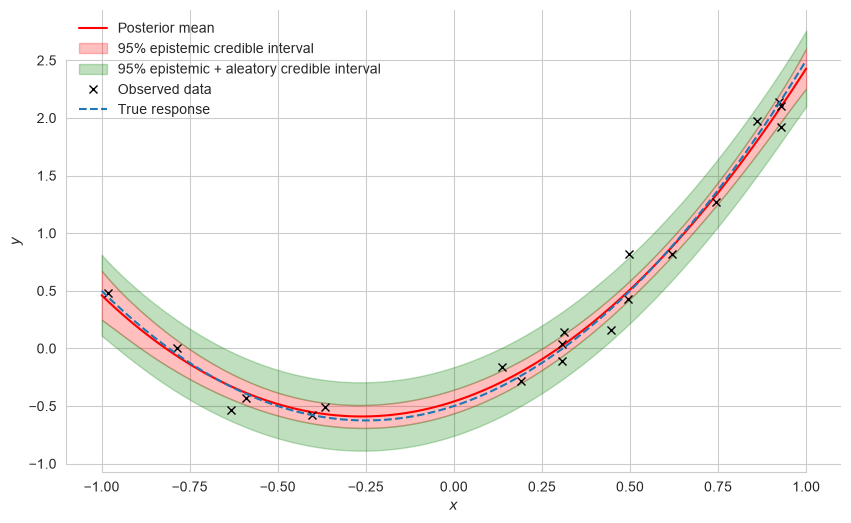

In [115]:
plot_posterior_predictive(
    model_ard, xx,
    get_polynomial_design_matrix,
    phi_func_args=(degree,),
    y_true=yy_true
)

### 4.9 Muestras del posterior sobre los pesos

En vez de graficar la media y el intervalo, podemos muestrear varios vectores $w$ del posterior $p(w \mid \text{datos})$ y graficar la curva $\phi(x)^T w$ para cada uno. Cada curva roja es una "hipotesis plausible" de la funcion verdadera.

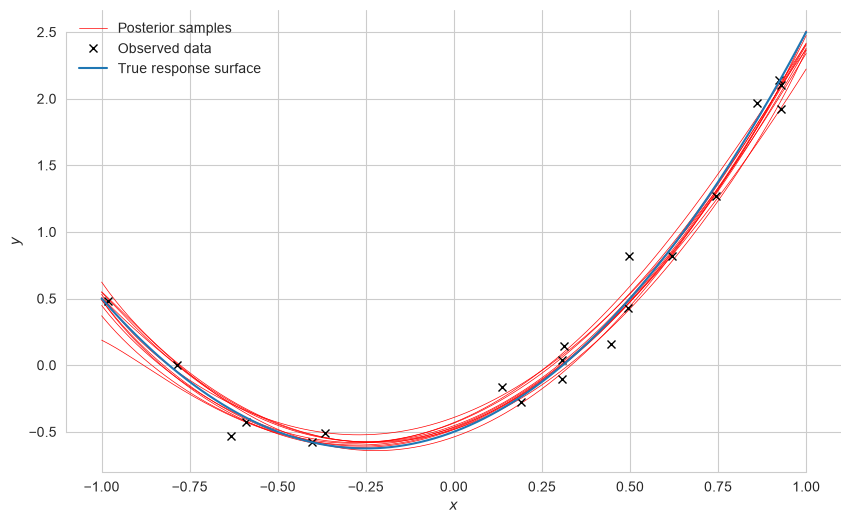

In [116]:
plot_posterior_samples(
    model_ard, xx,
    get_polynomial_design_matrix,
    phi_func_args=(degree,),
    y_true=yy_true
)

### 4.10 ARD vs Bayesian Ridge

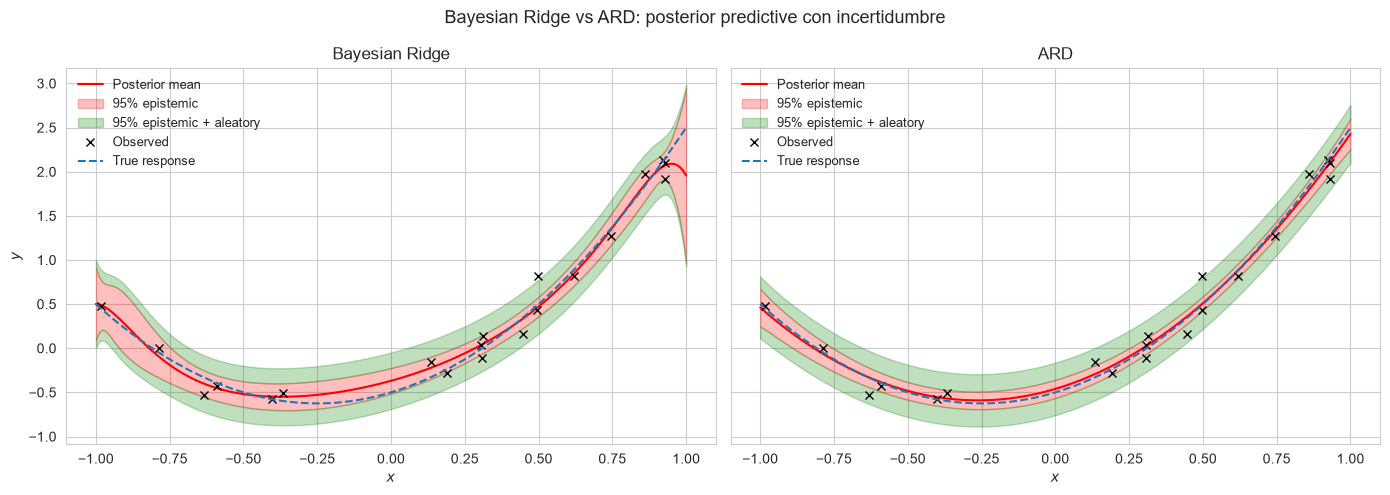

In [117]:
model_br = modelos['Bayesian Ridge']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (nombre, modelo) in zip(axes, [('Bayesian Ridge', model_br), ('ARD', model_ard)]):
    yy_mean, yy_measured_std = modelo.predict(Phi_xx, return_std=True)
    sigma_m = np.sqrt(1.0 / modelo.alpha_)
    yy_std = np.sqrt(np.clip(yy_measured_std ** 2 - sigma_m ** 2, 0, None))

    ax.plot(xx, yy_mean, 'r', label='Posterior mean')
    ax.fill_between(xx, yy_mean - 2 * yy_std, yy_mean + 2 * yy_std,
                    color='red', alpha=0.25, label='95% epistemic')
    ax.fill_between(xx, yy_mean - 2 * yy_measured_std, yy_mean - 2 * yy_std,
                    color='green', alpha=0.25)
    ax.fill_between(xx, yy_mean + 2 * yy_std, yy_mean + 2 * yy_measured_std,
                    color='green', alpha=0.25, label='95% epistemic + aleatory')
    ax.plot(x, y, 'kx', label='Observed')
    ax.plot(xx, yy_true, '--', label='True response')
    ax.set_title(nombre)
    ax.set_xlabel('$x$')
    ax.legend(loc='best', frameon=False, fontsize=9)

axes[0].set_ylabel('$y$')
plt.suptitle('Bayesian Ridge vs ARD: posterior predictive con incertidumbre', fontsize=13)
plt.tight_layout()
plt.show()

### 4.11 Conclusion

Sobre un unico dataset chico (20 observaciones) vimos que:

- **OLS overfittea** y las curvas oscilan, los coeficientes de grados altos son enormes.
- **Ridge y Bayesian Ridge** shrinkean todo por igual pero mantienen todas las bases activas.
- **ARD** identifica automaticamente que solo los grados 0, 1 y 2 aportan, apaga los demas ($\alpha_j$ enorme), recupera la curva verdadera y ademas provee incertidumbre epistemica + aleatoria.

Ahora veamos este mecanismo en un problema real.

## 5. Experimento con datos medicos reales

Usamos el dataset de Diabetes de scikit learn: 442 pacientes, 10 variables clinicas (edad, sexo, IMC, presion sanguinea, y 6 medidas de suero). El target es la progresion de la diabetes un ano despues.

Expandimos con features polinomicos, agregamos todos los productos de a pares y los cuadrados. Asi pasamos de 10 a 65 variables, muchas de las cuales seran ruido o combinaciones redundantes.

In [118]:
data = load_diabetes()
X_med = data.data
y_med = data.target
feature_names = data.feature_names

print(f'Muestras: {X_med.shape[0]}')
print(f'Features originales ({len(feature_names)}): {feature_names}')
print(f'Target (progresion): media={y_med.mean():.1f}, std={y_med.std():.1f}')

df_med = pd.DataFrame(X_med, columns=feature_names)
df_med['target'] = y_med
df_med.head()

Muestras: 442
Features originales (10): ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target (progresion): media=152.1, std=77.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [119]:
# Expandimos con features polinomicas
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_med_poly = poly.fit_transform(X_med)
poly_names = poly.get_feature_names_out(feature_names)

print(f'Features tras expansion polinomica: {X_med_poly.shape[1]}')

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_med_poly, y_med, test_size=0.3, random_state=42
)

scaler_m = StandardScaler()
X_train_m_s = scaler_m.fit_transform(X_train_m)
X_test_m_s = scaler_m.transform(X_test_m)

Features tras expansion polinomica: 65


### 5.1 Comparacion de los cuatro modelos

In [120]:
modelos_med = {
    'OLS': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Bayesian Ridge': BayesianRidge(),
    'ARD': ARDRegression()
}

resultados_med = {}
coefs_med = {}

for nombre, modelo in modelos_med.items():
    modelo.fit(X_train_m_s, y_train_m)
    y_pred = modelo.predict(X_test_m_s)
    cv_scores = cross_val_score(modelo, X_train_m_s, y_train_m,
                                cv=5, scoring='r2')
    resultados_med[nombre] = {
        'MSE_test': mean_squared_error(y_test_m, y_pred),
        'MAE_test': mean_absolute_error(y_test_m, y_pred),
        'R2_test': r2_score(y_test_m, y_pred),
        'R2_cv_mean': cv_scores.mean(),
        'R2_cv_std': cv_scores.std()
    }
    coefs_med[nombre] = modelo.coef_

pd.DataFrame(resultados_med).T.round(4)

,MSE_test,MAE_test,R2_test,R2_cv_mean,R2_cv_std
OLS,3168.9304,44.2214,0.4130,0.2156,0.2867
Ridge,2984.9585,42.6490,0.4471,0.3309,0.1738
Bayesian Ridge,2752.8180,41.9916,0.4901,0.4005,0.1472
ARD,2734.2741,41.2208,0.4935,0.4082,0.1503


En este dataset la mejora de ARD sobre Bayesian Ridge es marginal, ambos superan claramente a Ridge y OLS. La conclusion practica es que la principal razon para elegir ARD sobre Bayesian Ridge en este caso no es la precision sino la interpretabilidad (te dice cuales son las variables clinicas relevantes) y la parsimonia (modelo mas simple con menos coeficientes)

### 5.2 Que variables selecciona el ARD?

Miramos los coeficientes que sobrevivieron el shrinkage del ARD. Estas son las variables clinicas (o combinaciones) que el modelo considera realmente relevantes para predecir la progresion de la diabetes.

In [121]:
coef_ard_med = coefs_med['ARD']

df_coef = pd.DataFrame({
    'feature': poly_names,
    'coef_ARD': coef_ard_med,
    'abs_coef': np.abs(coef_ard_med)
}).sort_values('abs_coef', ascending=False)

print('Top 15 variables seleccionadas por ARD:')
print(df_coef.head(15).to_string(index=False))

umbral_med = 1e-3
n_activas_ard = np.sum(np.abs(coef_ard_med) > umbral_med)
n_activas_ridge = np.sum(np.abs(coefs_med['Ridge']) > umbral_med)
print(f'\nVariables activas (|coef| > {umbral_med}):')
print(f'  Ridge: {n_activas_ridge} de {len(poly_names)}')
print(f'  ARD:   {n_activas_ard} de {len(poly_names)}')

Top 15 variables seleccionadas por ARD:
feature   coef_ARD  abs_coef
    bmi  25.962466 25.962466
     bp  18.679481 18.679481
     s5  18.405311 18.405311
     s3 -17.872382 17.872382
 bmi bp   6.442108  6.442108
  s5 s6   5.792312  5.792312
  sex^2  -5.765913  5.765913
    sex  -5.765913  5.765913
age sex   5.364101  5.364101
   s3^2   5.255369  5.255369
   s5^2  -5.016989  5.016989
  bp s6  -4.993430  4.993430
   s6^2   3.236568  3.236568
  age^2   2.808434  2.808434
 age bp   2.291568  2.291568

Variables activas (|coef| > 0.001):
  Ridge: 65 de 65
  ARD:   34 de 65


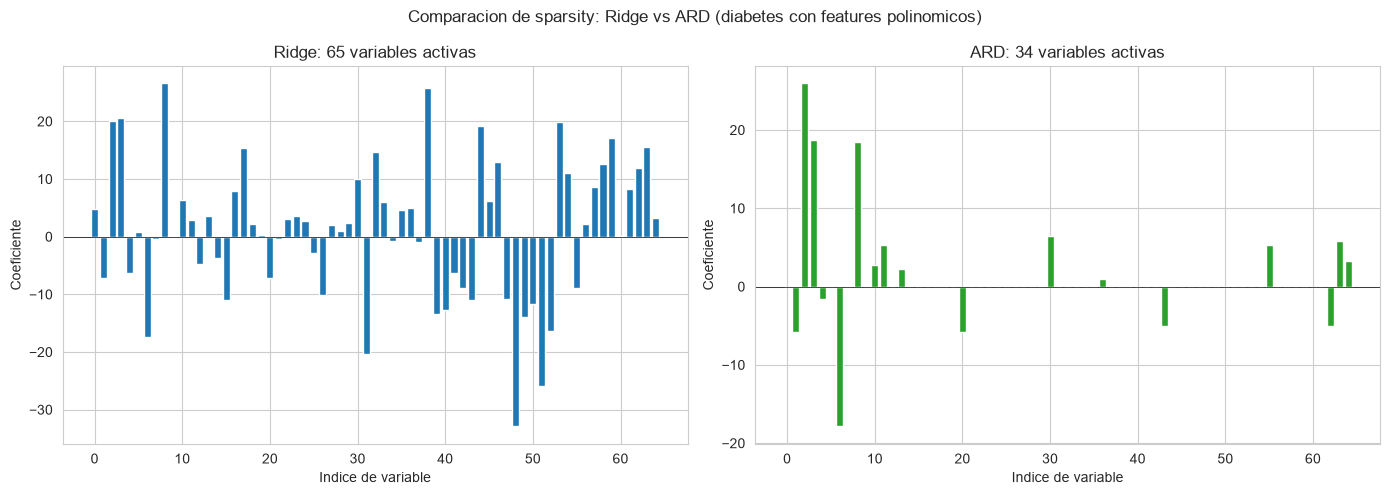

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(poly_names)), coefs_med['Ridge'], color='C0')
axes[0].set_title(f'Ridge: {n_activas_ridge} variables activas')
axes[0].set_xlabel('Indice de variable')
axes[0].set_ylabel('Coeficiente')
axes[0].axhline(0, color='k', lw=0.5)

axes[1].bar(range(len(poly_names)), coefs_med['ARD'], color='C2')
axes[1].set_title(f'ARD: {n_activas_ard} variables activas')
axes[1].set_xlabel('Indice de variable')
axes[1].set_ylabel('Coeficiente')
axes[1].axhline(0, color='k', lw=0.5)

plt.suptitle('Comparacion de sparsity: Ridge vs ARD (diabetes con features polinomicos)')
plt.tight_layout()
plt.show()

### 5.3 Precisiones $\alpha_j$ del ARD en el dataset medico

Las precisiones altas identifican variables descartadas

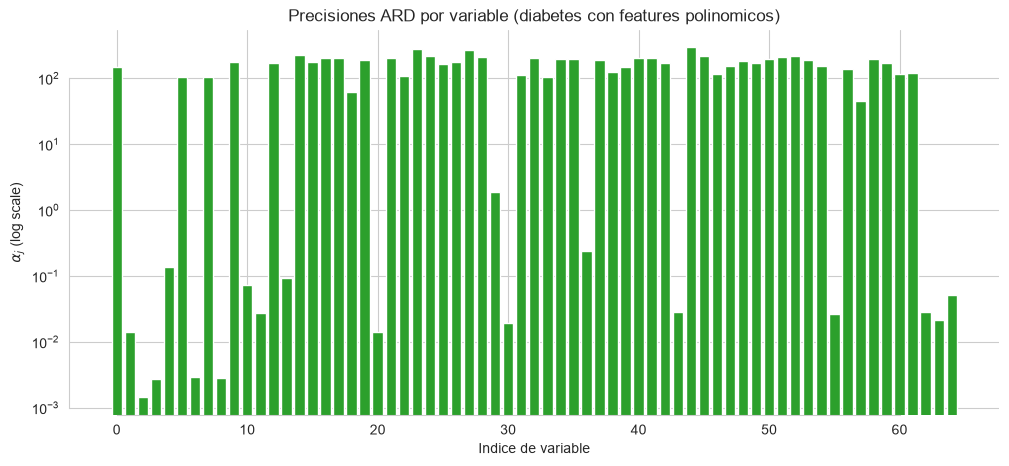

In [123]:
ard_med = modelos_med['ARD']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(poly_names)), ard_med.lambda_, color='C2')
ax.set_yscale('log')
ax.set_xlabel('Indice de variable')
ax.set_ylabel(r'$\alpha_j$ (log scale)')
ax.set_title('Precisiones ARD por variable (diabetes con features polinomicos)')
sns.despine(trim=True);

### 5.4 Interpretacion clinica

Las variables originales del dataset son:

- `age`: edad
- `sex`: sexo
- `bmi`: indice de masa corporal
- `bp`: presion sanguinea media
- `s1`: TC (colesterol total)
- `s2`: LDL (lipoproteinas de baja densidad)
- `s3`: HDL (lipoproteinas de alta densidad)
- `s4`: TCH (relacion TC/HDL)
- `s5`: LTG (log de nivel de trigliceridos)
- `s6`: nivel de azucar en sangre

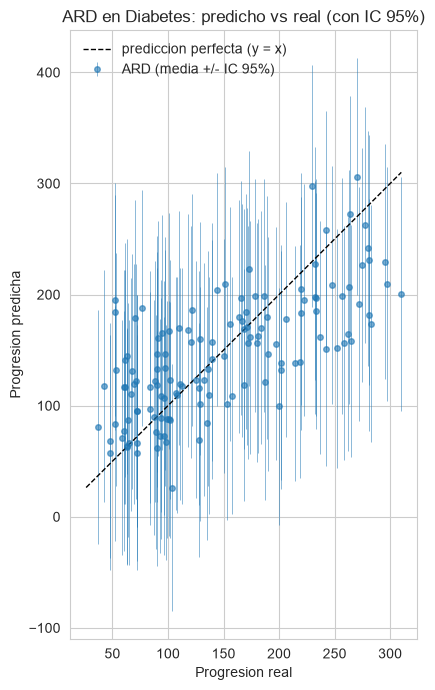

In [124]:
# Prediccion con intervalo de credibilidad en el dataset medico
y_pred_med, y_std_med = ard_med.predict(X_test_m_s, return_std=True)

fig, ax = plt.subplots(figsize=(7, 7))

# Barras de error verticales con el IC 95% de cada paciente
ax.errorbar(y_test_m, y_pred_med, yerr=1.96 * y_std_med,
            fmt='o', markersize=4, color='C0', ecolor='C0',
            elinewidth=0.6, alpha=0.6, label='ARD (media +/- IC 95%)')

# Recta y = x, prediccion perfecta
lo = min(y_test_m.min(), y_pred_med.min())
hi = max(y_test_m.max(), y_pred_med.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='prediccion perfecta (y = x)')

ax.set_xlabel('Progresion real')
ax.set_ylabel('Progresion predicha')
ax.set_title('ARD en Diabetes: predicho vs real (con IC 95%)')
ax.legend(loc='upper left', frameon=False)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

## 6. Resumen comparativo final

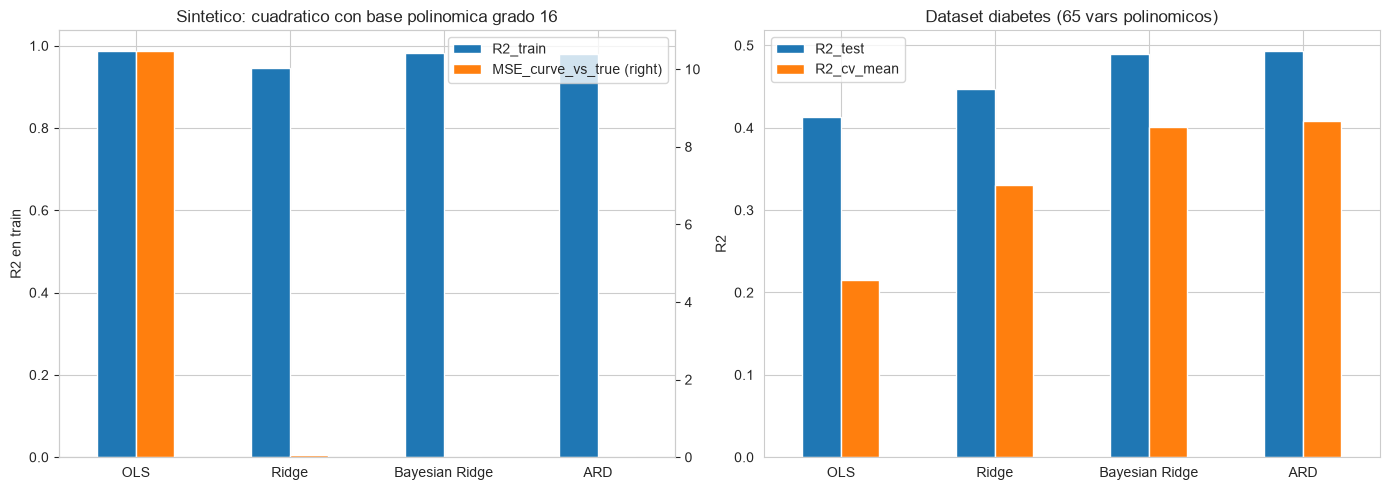

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_sint = pd.DataFrame(resultados).T[['R2_train', 'MSE_curve_vs_true']]
df_sint.plot(kind='bar', ax=axes[0], secondary_y='MSE_curve_vs_true')
axes[0].set_title('Sintetico: cuadratico con base polinomica grado 16')
axes[0].set_ylabel('R2 en train')
axes[0].tick_params(axis='x', rotation=0)

df_med_plot = pd.DataFrame(resultados_med).T[['R2_test', 'R2_cv_mean']]
df_med_plot.plot(kind='bar', ax=axes[1])
axes[1].set_title('Dataset diabetes (65 vars polinomicos)')
axes[1].set_ylabel('R2')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 7. Extension, NARD (Network ARD)

Un paper de 2025 extiende ARD a problemas con multiples outputs correlacionados (por ejemplo, si necesitaramos medir varios biomarcadores a la vez en cada paciente). La propuesta se llama NARD (Network ARD) y hace dos cosas al mismo tiempo, seleccionar features relevantes para todos los outputs (como ARD) y modelar la estructura de correlacion entre los outputs. Ademas propone variantes secuenciales y aproximaciones para bajar el costo computacional, que en la version basica escala mal cuando hay muchisimas variables.

Zhang, H., Ye, Z., Wang, X., Guo, X., Xu, Z., Cheng, Y., Hu, Z., y Qi, Y. (2025). Efficient Network Automatic Relevance Determination. En Proceedings of the 42nd International Conference on Machine Learning (ICML 2025). arXiv, 2506.12352. https://arxiv.org/abs/2506.12352

## 8. Conclusiones

1. ARD generaliza Bayesian Ridge asignando una precision distinta a cada coeficiente, lo que le permite hacer seleccion automatica de variables

2. No requiere hiperparametros externos, no hay que tunear alpha via cross validation, lo que simplifica el pipeline

3. Sus limitaciones son el costo computacional en datasets grandes, la asuncion de linealidad y la posible inestabilidad con features muy correlacionadas

4. NARD extiende la idea a problemas multi output correlacionados y aborda el costo computacional con variantes secuenciales y aproximaciones del marginal likelihood

5. En resumen: ARD (y sus extensiones) es una excelente eleccion cuando tenemos un dataset con muchas variables candidatas, sospechamos que solo unas pocas son relevantes, y necesitamos un modelo interpretable con estimaciones de incertidumbre